**Table of contents**
1. [Set up and config](#1)
2. [Xử lý dữ liệu](#2)
3. [Mô hình và huấn luyện mô hình](#3)
4. [Đánh giá mô hình](#4)

# 1. Set up and config <a id='1'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from abc import ABC, abstractmethod
from dataclasses import dataclass
import scipy
import sklearn
import random

In [2]:
from preprocessing import load_data
from utils import learning_curve

## Configuaration

In [3]:
SEED = 42
LEARNING_RATE = 0.01
MAX_ITER = 10_000
REG = 1e-6
DATA_PATH = '../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx'

In [4]:
def set_seed(seed: int) -> None:
  random.seed(seed)
  np.random.seed(seed)

set_seed(SEED)

# 2. Xử lý dữ liệu <a id='2'></a>
- Không validation:
$\text{Train} : \text{Test} = 80\% : 20\%$
- Có validation:
$\text{Train} : \text{Val} : \text{Test} = 60\% : 20\% : 20\%$

In [5]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

# 1. LOAD DATA
df = load_data(DATA_PATH)

# 2. SEPARATE TARGET FROM FEATURES IMMEDIATELY
# This prevents the 'Class' column from being treated as a feature during scaling
X = df.drop('Class', axis=1)
y = df['Class']

# 3. SPLIT DATA FIRST (To prevent Data Leakage)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

# 4. IDENTIFY COLUMN TYPES ON X_TRAIN
non_numeric_cols = X_train.select_dtypes(exclude=[np.number]).columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns

# 5. IMPUTATION (Fit on Train, Transform on both)
# Numeric Imputer
num_imputer = SimpleImputer(strategy='mean')
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical Imputer (If there are any non-numeric features)
if not non_numeric_cols.empty:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    X_train[non_numeric_cols] = cat_imputer.fit_transform(X_train[non_numeric_cols])
    X_test[non_numeric_cols] = cat_imputer.transform(X_test[non_numeric_cols])

# 6. ENCODE FEATURES (If any)
label_encoders = {}
for col in non_numeric_cols:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    label_encoders[col] = le

# 7. ENCODE TARGET (y)
# 'Class' in Dry Bean is text (Seki, Barbunya, etc.), must be numbers for most models
target_le = LabelEncoder()
y_train = target_le.fit_transform(y_train)
y_test = target_le.transform(y_test)

# 8. STANDARDIZATION
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_val, X_val, y_train_val, y_val = train_test_split(X_train_scaled, y_train, test_size=0.25, random_state=SEED)

Data loaded successfully from ../../data/raw/dry-bean-dataset/Dry_Bean_Dataset.xlsx


In [6]:
print(f"X_train_scaled.shape: {X_train_scaled.shape}")
print(f"y_train.shape: {y_train.shape}")
print(f"X_test_scaled.shape: {X_test_scaled.shape}")
print(f"y_test.shape: {y_test.shape}")

X_train_scaled.shape: (10888, 16)
y_train.shape: (10888,)
X_test_scaled.shape: (2723, 16)
y_test.shape: (2723,)


In [7]:
print(f"X_train_val.shape: {X_train_val.shape}")
print(f"y_train_val.shape: {y_train_val.shape}")
print(f"X_val.shape: {X_val.shape}")
print(f"y_val.shape: {y_val.shape}")

X_train_val.shape: (8166, 16)
y_train_val.shape: (8166,)
X_val.shape: (2722, 16)
y_val.shape: (2722,)


In [8]:
C = np.unique(y_train).shape[0]
print(f"Target classes identified: {target_le.classes_}")
print(f"Number of classes (C): {C}")


Target classes identified: ['BARBUNYA' 'BOMBAY' 'CALI' 'DERMASON' 'HOROZ' 'SEKER' 'SIRA']
Number of classes (C): 7


# 3. Mô hình và huấn luyện mô hình <a id='3'></a>

## 3.1 Logistic Regression (nhị phân và đa lớp)

## 3.2 Linear Discriminant Analysis - LDA và QDA

### 3.2.1 LDA và QDA

#### LDA

In [12]:
from models import LDA

lda = LDA(reg=REG)
lda.fit(X=X_train_scaled, y=y_train)
lda_preds = lda.predict(X=X_test_scaled)

#### QDA

In [ ]:
from models import QDA

qda = QDA(reg=REG)
qda.fit(X=X_train_scaled, y=y_train)
qda_preds = qda.predict(X=X_test_scaled)

### 3.2.2 Fisher ratio feature ranking

For each feature $x_j$, we treat the projection direction as selecting that single coordinate, so the Fisher criterion becomes

$$
J(w_j) = J_j = \frac{\sum_{c=1}^{C} n_c (\mu_{c,j} - \mu_j)^2}{\sum_{c=1}^{C} n_c \, \sigma_{c,j}^2}
$$

where $n_c$ is the number of training samples in class $c$, $\mu_{c,j}$ and $\sigma_{c,j}^2$ are the class-wise mean and variance of feature $j$, and $\mu_j$ is the global mean of feature $j$. A larger $J_j$ means the feature separates classes better relative to its within-class spread.

In [ ]:
# Fisher ratio for each feature (multiclass version)
# J_j = sum_c n_c (mu_cj - mu_j)^2 / sum_c n_c sigma_cj^2

feature_names = list(X_train.columns)

classes, counts = np.unique(y_train, return_counts=True)
overall_mean = X_train_scaled.mean(axis=0)
fisher_scores = []

for j in range(X_train_scaled.shape[1]):
  between_class = 0.0
  within_class = 0.0

  for cls, n_c in zip(classes, counts):
    x_c = X_train_scaled[y_train == cls, j]
    mu_c = x_c.mean()
    var_c = x_c.var(ddof=1)

    between_class += n_c * (mu_c - overall_mean[j]) ** 2
    within_class += n_c * var_c

  fisher_scores.append(between_class / (within_class + 1e-12))

fisher_df = pd.DataFrame({
  'feature': feature_names,
  'fisher_ratio': fisher_scores,
}).sort_values('fisher_ratio', ascending=False).reset_index(drop=True)

print('Fisher ratio ranking (higher is better):')
fisher_df


Fisher ratio ranking (higher is better):


,feature,fisher_ratio
0,Area,12.553347
1,ConvexArea,12.530033
2,EquivDiameter,11.084359
3,Perimeter,10.629966
4,MinorAxisLength,9.701366
5,MajorAxisLength,9.472088
6,ShapeFactor2,5.381678
7,ShapeFactor1,5.307530
8,AspectRation,4.511665
9,Compactness,4.413558


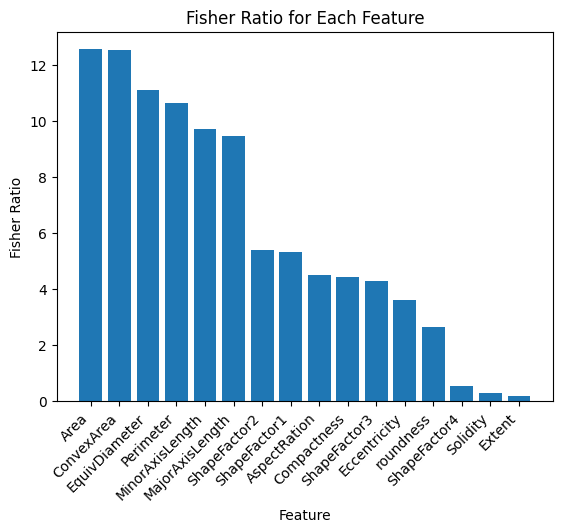

In [ ]:
plt.bar(fisher_df['feature'], fisher_df['fisher_ratio'])
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.ylabel('Fisher Ratio')
plt.title('Ranking of Fisher Ratio for Each Feature')

plt.show()

### 3.2.3 Vẽ quy chiếu LDA xuống 2D và biểu diễn đường quyết định

## 3.3 Perceptron và Logistic Regression có Regularization

# 4. Đánh giá mô hình <a id='4'></a>